In [80]:
from automata.fa.nfa import NFA
from automata.fa.dfa import DFA

input_states = input("Enter set of states:").split(" ")
input_symbols = input("Enter set of input symbols:").split(" ")
transitions = {}
builder = {}
for state in input_states:
    for symbol in input_symbols:
        hold = set(input("Enter next states for symbol " + symbol + " on the state " + state + ":").split(" "))
        if hold != {''}:
            builder[symbol] = hold 
    transitions[state] = builder
    builder = {}
initial_state = input("Enter initial state:")
final_states = input("Enter set of final states state:").split(" ")
my_nfa = NFA(
    states=set(input_states),
    input_symbols=set(input_symbols),
    transitions=transitions,
    initial_state=initial_state,
    final_states=set(final_states),
)

Enter set of states: 1 2 3 4 5 6
Enter set of input symbols: a b
Enter next states for symbol a on the state 1: 2
Enter next states for symbol b on the state 1: 4
Enter next states for symbol a on the state 2: 4
Enter next states for symbol b on the state 2: 3
Enter next states for symbol a on the state 3: 3
Enter next states for symbol b on the state 3: 3
Enter next states for symbol a on the state 4: 4
Enter next states for symbol b on the state 4: 5
Enter next states for symbol a on the state 5: 5
Enter next states for symbol b on the state 5: 5
Enter next states for symbol a on the state 6: 6
Enter next states for symbol b on the state 6: 5
Enter initial state: 1
Enter set of final states state: 3 5


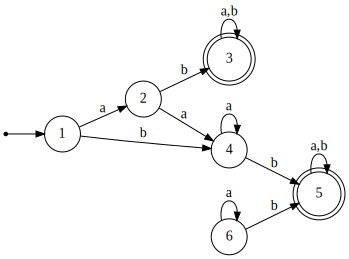

In [81]:
my_nfa.show_diagram()

In [82]:
indis = [[1 for i in range(len(input_states) - 1)] for j in range(len(input_states) - 1)]
indis

[[1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1]]

In [83]:
indis = [[0 for i in range(len(input_states) - 1)] for j in range(len(input_states) - 1)]

In [84]:
indis[4][1]= 1

In [85]:
indis[2][1]= 1

In [86]:
indis[3][2]= 1

In [87]:
indis[4][3]= 1

In [88]:
for state_x in indis:
    print(state_x)

[0, 0, 0, 0, 0]
[0, 0, 0, 0, 0]
[0, 1, 0, 0, 0]
[0, 0, 1, 0, 0]
[0, 1, 0, 1, 0]


In [99]:
push = 1
state_list = list(input_states)
states = {}
added = False
for y in range(len(indis)):
    for x in range(push):
        if indis[y][x] == 1:
            added = True
            if state_list[y+1] in states:
                states[state_list[y+1]].add(state_list[x])
            else:
                states[state_list[y+1]] = {state_list[x]}
    push += 1
    if not added:
        if y == 0:
            states[state_list[y]] = {}
        else:
            states[state_list[y+1]] = {}
    added = False
print(states)

{'1': {}, '3': {}, '4': {'2'}, '5': {'3'}, '6': {'2', '4'}}


In [100]:
new_states = []
curr = set()
for curr_state in states:
    curr.add(curr_state)
    for state in states:
        for substate in states[state]:
            if state in curr or substate in curr:
                curr.add(state)
                addall = True
            if addall:
                curr.add(substate)
        addall = False
    if curr not in new_states:
        new_states.append(curr)
    curr = set()
print(new_states)

[{'1'}, {'5', '3'}, {'2', '6', '4'}]


In [112]:
new_state = []
new_final = []
new_ini = False
new_fin = False
for state in new_states:
    hold = ""
    for prev in state:
        if prev == initial_state:
            new_ini = True
        if prev in final_states:
            new_fin = True
        hold = hold + prev
    if new_ini:
        new_ini = not new_ini
        new_initial = hold
    if new_fin:
        new_fin = not new_fin
        new_final.append(hold)
    new_state.append(hold)
new_state

['1', '53', '264']

In [124]:
transitions

{'1': {'a': {'2'}, 'b': {'4'}},
 '2': {'a': {'4'}, 'b': {'3'}},
 '3': {'a': {'3'}, 'b': {'3'}},
 '4': {'a': {'4'}, 'b': {'5'}},
 '5': {'a': {'5'}, 'b': {'5'}},
 '6': {'a': {'6'}, 'b': {'5'}}}

In [122]:
new_transitions = {'1': {'a':{'264'}, 'b': {'264'}}, '264' : {'a':{'264'},'b':{'53'}},'53':{'a':{'53'},'b':{'53'}}}

In [125]:
new_nfa = NFA(
    states=set(new_state),
    input_symbols=set(input_symbols),
    transitions=new_transitions,
    initial_state=new_initial,
    final_states=set(new_final),
)

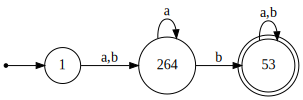

In [126]:
new_nfa.show_diagram()

In [1]:
import os
import matplotlib.pyplot as plt
from IPython.display import display
from graphviz import Digraph

from automata.fa.dfa import DFA
from solution import Solution

def minimize_dfa_steps(dfa):
    """
    Performs iterative partition refinement for DFA minimization.
    Returns a list of partitions, where each partition is a list of blocks (each block is a set of states).
    
    The algorithm starts with:
      P0 = { Final states, Non-final states }
    and then refines until the partition is stable.
    
    Parameters:
      dfa: a DFA object with attributes:
           - dfa.states (set of states)
           - dfa.input_symbols (set of symbols)
           - dfa.transitions (dict mapping state to dict of {symbol: target_state})
           - dfa.final_states (set)
           
    Returns:
      partitions: a list of partitions (one per iteration).
    """
    partitions = []
    
    F = set(dfa.final_states)
    Q = set(dfa.states)
    nonF = Q - F
    # Initial partition: only add nonempty blocks
    P = []
    if F:
        P.append(F)
    if nonF:
        P.append(nonF)
    partitions.append(P)
    
    changed = True
    while changed:
        new_P = []
        # For each block in the partition, refine it.
        for block in P:
            # Use a dictionary to separate states by their "transition signature":
            # For each state, build a tuple of indices (one per input symbol)
            # indicating which block its target state falls into (or None if target not found).
            groups = {}
            for state in block:
                key = []
                for symbol in dfa.input_symbols:
                    target = dfa.transitions.get(state, {}).get(symbol, None)
                    # Identify the block index in which the target lies (if any).
                    target_block = None
                    for i, b in enumerate(P):
                        if target in b:
                            target_block = i
                            break
                    key.append(target_block)
                key = tuple(key)
                if key not in groups:
                    groups[key] = set()
                groups[key].add(state)
            # Each group is a refined block.
            new_P.extend(groups.values())
        # Check if the partition changed.
        if new_P == P:
            changed = False
        else:
            P = new_P
            partitions.append(P)
    return partitions

def record_detailed_minimization_steps(dfa):
    """
    Runs the DFA minimization refinement process and creates details for each step.
    
    Returns:
       steps: list of partitions at each refinement iteration.
       details: list of dictionaries with a description and step number.
    """
    steps = minimize_dfa_steps(dfa)
    details = []
    for i, part in enumerate(steps):
        # Create a string representation for the partition
        part_str = "; ".join([", ".join(sorted(list(block))) for block in part])
        detail = {
            "step": i,
            "partition": [sorted(list(b)) for b in part],
            "description": f"Step {i+1}: Partitioned into {len(part)} block(s) -- {part_str}"
        }
        details.append(detail)
    return steps, details

# --- Visualization Functions for Minimization Steps ---

def plot_minimization_configuration(partition, step):
    """
    Creates a matplotlib figure showing the partition configuration.
    Each block is drawn as a rectangle with the states listed inside.
    
    Parameters:
      partition: a list of blocks (each block is a set of states) for this minimization step.
      step: integer indicating which step (iteration) this is.
    
    Returns:
      fig: a matplotlib figure object.
    """
    fig, ax = plt.subplots(figsize=(10, 3))
    num_blocks = len(partition)
    
    # We'll draw each block next to each other with a fixed width and some spacing.
    block_width = 2
    spacing = 0.5
    x = 0
    for block in partition:
        # Draw a rectangle for this block.
        rect = plt.Rectangle((x, 0), block_width, 1, facecolor="#e0f7fa", edgecolor="black", lw=2)
        ax.add_patch(rect)
        # Get a string of the states in this block.
        states_str = ", ".join(sorted(list(block)))
        ax.text(x + block_width/2, 0.5, states_str, ha="center", va="center", fontsize=12, fontweight="bold")
        x += block_width + spacing
    # Remove the axis and add a title.
    ax.set_xlim(0, x)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(f"Minimization Step {step+1}", fontsize=16, fontweight="bold", pad=20)
    plt.tight_layout()
    return fig

def plot_all_minimization_steps(steps):
    """
    Iterates through all minimization steps and creates a list of figures for visualization.
    
    Parameters:
      steps: list of partitions (each partition is a list of blocks) from minimization.
    
    Returns:
      plots: list of matplotlib figure objects.
    """
    plots = []
    for i, partition in enumerate(steps):
        fig = plot_minimization_configuration(partition, i)
        plots.append(fig)
        fig.savefig(f"out/plots/plot{i}.png")
    return plots




ModuleNotFoundError: No module named 'graphviz'

In [ ]:
def show_minimized_dfa_graphviz(dfa, layout="dot", filename=None):
    """
    Render a clean DFA diagram using Graphviz:
      - Initial state: bold outline
      - Final states: doublecircle, light fill
      - Transitions labeled on edges
      - Left-to-right (LR) layout by default
    If `filename` is provided, saves to <filename>.png and opens it.
    Otherwise, displays inline.
    """
    dot = Digraph(format='png')
    dot.attr(rankdir="LR", size="8,5")
    
    # Nodes
    for state in dfa.states:
        if state == dfa.initial_state:
            dot.node(state, shape='circle', style='bold')
        elif state in dfa.final_states:
            dot.node(state, shape='doublecircle', style='filled', fillcolor='lightgrey')
        else:
            dot.node(state, shape='circle')
    
    # Edges
    for src, trans in dfa.transitions.items():
        for sym, tgt in trans.items():
            dot.edge(src, tgt, label=sym)
    
    if filename:
        # writes filename.png
        dot.render(filename, view=True)
    else:
        display(dot)

# --- Build and Minimize the DFA ---

dfa = DFA(
    states={"1", "2", "3", "4", "5", "6", "Z"},
    input_symbols={"a", "b"},
    transitions={
        "1": {"a": "2", "b": "4"},
        "2": {"a": "4", "b": "3"},
        "3": {"a": "3", "b": "3"},
        "4": {"a": "2", "b": "5"},
        "5": {"a": "6", "b": "5"},
        "6": {"a": "4", "b": "Z"},
        "Z": {"a": "Z", "b": "Z"},
    },
    initial_state="1",
    final_states={"3"}
)

# 1) Compute minimization partitions & details
steps, details = record_detailed_minimization_steps(dfa)
plots = plot_all_minimization_steps(steps)

# 2) (Optional) Construct the actual minimized DFA from the last partition:
#    Here each block becomes a single state, transitions are induced accordingly.
#    For brevity, let’s assume you’ve built `min_dfa` correctly.
#
#    min_dfa = build_minimized_dfa_from_partitions(dfa, steps[-1])

# 3) Show a polished Graphviz diagram of the (minimized) DFA:
#    If you haven’t built `min_dfa`, you can render the original `dfa` instead.
show_minimized_dfa_graphviz(dfa, layout="dot", filename="out/minimized_dfa")

# --- Integrate with Your Document Builder ---

data = {
    "plots": plots,
    "tf": dfa.transitions,
    "details": details
}

my_Solution = Solution("templates", "out/dfa_minimization.tex")
my_Solution.add_dynamic_content("body.tex", data)
my_Solution.generate_latex()
my_Solution.generate_pdf()
